In [1]:
import numpy as np
import pandas as pd
# import matplotlib.pyplot as plt
from sklearn.preprocessing import scale 
from sklearn import model_selection
from sklearn.model_selection import RepeatedKFold
from sklearn.model_selection import train_test_split
from sklearn.cross_decomposition import PLSRegression
from sklearn.metrics import mean_squared_error
from sklearn import model_selection
from sklearn.model_selection import train_test_split, cross_val_score, cross_val_predict
from sys import stdout
import numpy as np
import pandas as pd
# import matplotlib.pyplot as plt
import matplotlib.pyplot as plt
import csv
from scipy.signal import savgol_filter
from scipy.stats import pearsonr
from sklearn.cross_decomposition import PLSRegression
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import mean_squared_error, r2_score

In [2]:
df_svc_RDMC=  pd.read_csv(r"E:\wenqu\2026_root\cluster\test2\CLUSTER\root_trait_RDMC.csv")
df_svc_SRL=  pd.read_csv(r"E:\wenqu\2026_root\cluster\test2\CLUSTER\root_trait_SRL.csv")
df_svc_RTD =  pd.read_csv(r"E:\wenqu\2026_root\cluster\test2\CLUSTER\root_trait_RTD.csv")
df_svc_RD=  pd.read_csv(r"E:\wenqu\2026_root\cluster\test2\CLUSTER\root_trait_RD.csv")
df_svc_SRA= pd.read_csv(r"E:\wenqu\2026_root\cluster\test2\CLUSTER\root_trait_SRA.csv")
df_svc_RBD=  pd.read_csv(r"E:\wenqu\2026_root\cluster\test2\CLUSTER\root_trait_RBD.csv")
df_svc_RLD=  pd.read_csv(r"E:\wenqu\2026_root\cluster\test2\CLUSTER\root_trait_RLD.csv")

df_svc_RCC=  pd.read_csv(r"E:\wenqu\2026_root\cluster\test2\CLUSTER\root_trait_RCC.csv")
df_svc_RD13C = pd.read_csv(r"E:\wenqu\2026_root\cluster\test2\CLUSTER\root_trait_RD13C.csv")
df_svc_RNC =  pd.read_csv(r"E:\wenqu\2026_root\cluster\test2\CLUSTER\root_trait_RNC.csv")
df_svc_RD15N=  pd.read_csv(r"E:\wenqu\2026_root\cluster\test2\CLUSTER\root_trait_RD15N.csv")
df_svc_RCN= pd.read_csv(r"E:\wenqu\2026_root\cluster\test2\CLUSTER\root_trait_RCN.csv")
df_svc_RCC= pd.read_csv(r"E:\wenqu\2026_root\cluster\test2\CLUSTER\root_trait_RCC.csv")


In [3]:
b_name = []

for i in range(1, 122):
    b_mean = 'b' + str(i) 
    b_name.append(b_mean)
    b_std = 'd' + str(i)
    # b_std = 'b' + str(i) + '_std'
    b_name.append(b_std)


# b_name = np.array(b_name)
# b_name

In [4]:
cols_rdmc = b_name + ["CWM_log10_LDMC", "DS_relative_abund_sum", "ES_relative_abund_sum", "F_relative_abund_sum", "G_relative_abund_sum", "M_relative_abund_sum"]
cols_srl = b_name+ ["CWM_log10_SLA"]+ ["CWM_log10_LA"]+ ["CWM_log10_LDMC"] + ["DS_relative_abund_sum"]+ ["ES_relative_abund_sum"]+ ["F_relative_abund_sum"]+ ["G_relative_abund_sum"]+ ["M_relative_abund_sum"]

cols_rtd = b_name+ ["CWM_log10_SLA"] + ["CWM_log10_LDMC"] + ["DS_relative_abund_sum"]+ ["ES_relative_abund_sum"]+ ["F_relative_abund_sum"]+ ["G_relative_abund_sum"]+ ["M_relative_abund_sum"]

cols_rd = b_name+ ["CWM_log10_LDMC"] + ["DS_relative_abund_sum"]+ ["ES_relative_abund_sum"]+ ["F_relative_abund_sum"]+ ["G_relative_abund_sum"]+ ["M_relative_abund_sum"]


cols_sra = b_name + ["CWM_log10_SLA"] + ["CWM_log10_LDMC"] + ["DS_relative_abund_sum"]+ ["ES_relative_abund_sum"]+ ["F_relative_abund_sum"]+ ["G_relative_abund_sum"]+ ["M_relative_abund_sum"]
cols_rbd = b_name+ ["CWM_log10_LA"] + ["DS_relative_abund_sum"]+ ["ES_relative_abund_sum"]+ ["F_relative_abund_sum"]+ ["G_relative_abund_sum"]+ ["M_relative_abund_sum"]
cols_rld = b_name+ ["DS_relative_abund_sum"]+ ["ES_relative_abund_sum"]+ ["F_relative_abund_sum"]+ ["G_relative_abund_sum"]+ ["M_relative_abund_sum"]

cols_rcc = b_name+ ["CWM_log10_PC"] + ["DS_relative_abund_sum"]+ ["ES_relative_abund_sum"]+ ["F_relative_abund_sum"]+ ["G_relative_abund_sum"]+ ["M_relative_abund_sum"]
cols_rd13c = b_name+ ["CWM_Ld13C"] + ["DS_relative_abund_sum"]+ ["ES_relative_abund_sum"]+ ["F_relative_abund_sum"]+ ["G_relative_abund_sum"]+ ["M_relative_abund_sum"]
cols_rnc = b_name+ ["CWM_log10_PN"] + ["DS_relative_abund_sum"]+ ["ES_relative_abund_sum"]+ ["F_relative_abund_sum"]+ ["G_relative_abund_sum"]+ ["M_relative_abund_sum"]

cols_rd15n = b_name+ ["CWM_Ld15N"] + ["DS_relative_abund_sum"]+ ["ES_relative_abund_sum"]+ ["F_relative_abund_sum"]+ ["G_relative_abund_sum"]+ ["M_relative_abund_sum"]

cols_rcn = b_name+ ["CN_ratio"] + ["DS_relative_abund_sum"]+ ["ES_relative_abund_sum"]+ ["F_relative_abund_sum"]+ ["G_relative_abund_sum"]+ ["M_relative_abund_sum"]

In [5]:
x_RDMC = np.array(df_svc_RDMC[cols_rdmc] )
x_SRL = np.array(df_svc_SRL[cols_srl])
x_RTD = np.array(df_svc_RTD[cols_rtd])
x_RD = np.array(df_svc_RD[cols_rd])
x_SRA = np.array(df_svc_SRA[cols_sra])
x_RBD = np.array(df_svc_RBD[cols_rbd])
x_RLD = np.array(df_svc_RLD[cols_rld])
x_RD13C = np.array(df_svc_RD13C[cols_rd13c])
x_RNC = np.array(df_svc_RNC[cols_rnc])
x_RD15N = np.array(df_svc_RD15N[cols_rd15n])
x_RCN = np.array(df_svc_RCN[cols_rcn])
x_RCC = np.array(df_svc_RCC[cols_rcc])

In [6]:
labels_RDMC = [] 
for i in range(len(df_svc_RDMC['site'])):    
    site_name = df_svc_RDMC['site'][i].split("_")[0]
    labels_RDMC.append(site_name)


labels_SRL = [] 
for i in range(len(df_svc_SRL['site'])):    
    site_name = df_svc_SRL['site'][i].split("_")[0]
    labels_SRL.append(site_name)


labels_RTD = [] 
for i in range(len(df_svc_RTD['site'])):    
    site_name = df_svc_RTD['site'][i].split("_")[0]
    labels_RTD.append(site_name)

In [7]:
labels_RD = [] 
for i in range(len(df_svc_RD['site'])):    
    site_name = df_svc_RD['site'][i].split("_")[0]
    labels_RD.append(site_name)
# labels_pc

labels_SRA = [] 
for i in range(len(df_svc_SRA['site'])):    
    site_name = df_svc_SRA['site'][i].split("_")[0]
    labels_SRA.append(site_name)


labels_RBD = [] 
for i in range(len(df_svc_RBD['site'])):    
    site_name = df_svc_RBD['site'][i].split("_")[0]
    labels_RBD.append(site_name)

In [8]:
labels_RLD = [] 
for i in range(len(df_svc_RLD['site'])):    
    site_name = df_svc_RLD['site'][i].split("_")[0]
    labels_RLD.append(site_name)
# labels_pc

labels_RD13C = [] 
for i in range(len(df_svc_RD13C['site'])):    
    site_name = df_svc_RD13C['site'][i].split("_")[0]
    labels_RD13C.append(site_name)


labels_RNC = [] 
for i in range(len(df_svc_RNC['site'])):    
    site_name = df_svc_RNC['site'][i].split("_")[0]
    labels_RNC.append(site_name)


labels_RD15N = [] 
for i in range(len(df_svc_RD15N['site'])):    
    site_name = df_svc_RD15N['site'][i].split("_")[0]
    labels_RD15N.append(site_name)


labels_RCN = [] 
for i in range(len(df_svc_RCN['site'])):    
    site_name = df_svc_RCN['site'][i].split("_")[0]
    labels_RCN.append(site_name)



labels_RCC = [] 
for i in range(len(df_svc_RCC['site'])):    
    site_name = df_svc_RCC['site'][i].split("_")[0]
    labels_RCC.append(site_name)

In [9]:
y_RDMC = df_svc_RDMC['RDMC_A'].to_numpy()
y_SRL = df_svc_SRL['SRL'].to_numpy()
y_RTD = df_svc_RTD['RTD'].to_numpy()
y_RD = df_svc_RD['RD'].to_numpy()
y_SRA = df_svc_SRA['SRA'].to_numpy()
y_RBD = df_svc_RBD['RBD'].to_numpy()
y_RLD = df_svc_RLD['RLD'].to_numpy()
y_RCC = df_svc_RCC['RCC'].to_numpy()
y_RD13C = df_svc_RD13C['Rd13C'].to_numpy()

y_RNC = df_svc_RNC['RNC'].to_numpy()
y_RD15N = df_svc_RD15N['Rd15N'].to_numpy()
y_RCN = df_svc_RCN['RCN'].to_numpy()

In [10]:
def optimise_pls_band_component(X, y, max_comp):
    
    # Define an MSE array to be populated
    mse = np.zeros((max_comp, X.shape[1] - max_comp +1 ))



    # Loop over the number of PLS components
    for i in range(max_comp):
        # print(i)
        
        # Regression with the specified number of components, using the full spectrum
        pls1 = PLSRegression(n_components=i + 1)
        pls1.fit(X, y)
        
        # Indices of sorted spectra according to ascending absolute value of PLS coefficients
        sorted_ind = np.argsort(np.abs(pls1.coef_.flatten()))
 
        # Sort spectra accordingly
        Xc = X[:, sorted_ind]
        
        max_j = min(Xc.shape[1] - (i + 1), mse.shape[1]) 
        # Discard one wavelength at a time from the sorted spectra,
        # regress, and calculate the MSE cross-validation
        for j in range(max_j): 
            pls2 = PLSRegression(n_components=i + 1)
            pls2.fit(Xc[:, j:], y)
            
            y_cv = cross_val_predict(pls2, Xc[:, j:], y.astype(np.float64), cv=10)
          

            mse[i, j] = np.sqrt(mean_squared_error(y, y_cv))        
            

      

    
    stdout.write("\n")
    
    # Find the indices of the minimum non-NaN MSE values
    mseminx,mseminy = np.where(mse==np.min(mse[np.nonzero(mse)]))

    
    print("Optimised number of PLS components: ", mseminx[0] + 1)
    print("Wavelengths to be kept ", (X.shape[1] - mseminy[0]))
    print('Optimised MSEP ', mse[mseminx, mseminy][0])
    stdout.write("\n")
 
    # Calculate PLS with optimal components and export values
    optimal_pls = PLSRegression(n_components=mseminx[0] + 1)
    optimal_pls.fit(X, y)
        
    sorted_ind = np.argsort(np.abs(optimal_pls.coef_.flatten()))
 
    Xc = X[:, sorted_ind]
 
    return Xc[:, mseminy[0]:], mseminx[0] + 1, mseminy[0], sorted_ind

In [11]:


def simple_pls_cv_label_category(X, y, n_comp, labels, filename):

    # Run PLS with suggested number of components
    pls = PLSRegression(n_components=n_comp)
    pls.fit(X, y)
    y_c = pls.predict(X)
    print(y_c)

    # Cross-validation
    y_cv = cross_val_predict(pls, X, y, cv=10)


    # Calculate scores for calibration and cross-validation
    score_c = r2_score(y, y_c)
    score_cv = r2_score(y, y_cv)

    # Calculate mean square error for calibration and cross validation
#     mse_c = mean_squared_error(y, y_c)
#     mse_cv = mean_squared_error(y, y_cv)
    rmse_c = np.sqrt(mean_squared_error(y, y_c))

    rmse_cv = np.sqrt(mean_squared_error(y, y_cv))  


    print('R2 calib: %5.3f'  % score_c)
    print('R2 CV: %5.3f'  % score_cv)
#     print('MSE calib: %5.3f' % mse_c)
#     print('MSE CV: %5.3f' % mse_cv)
    print('RMSE calib: %5.3f' % rmse_c)
    print('RMSE CV: %5.3f' % rmse_cv)

    # Plot regression 
    z = np.polyfit(y, y_cv, 1)
    print(z[1],z[0])
    with plt.style.context(('ggplot')):
        fig, ax = plt.subplots(figsize=(9, 5))

        # Define a dictionary of labels and their corresponding markers and colors
        # Define label styles
        label_dict = {
            'S3C': {'marker': 'o', 'color': 'purple'},     # circle
            'S4' : {'marker': 's', 'color': 'blue'},       # square
            'S6' : {'marker': 'D', 'color': 'orange'},     # diamond
            'S6A': {'marker': 'p', 'color': 'cyan'},       # pentagon
            'S7' : {'marker': '^', 'color': 'brown'},      # triangle up
            'S2C': {'marker': 'v', 'color': 'green'},      # triangle down
            'S1B': {'marker': 'X', 'color': 'red'},        # X
            'S2A': {'marker': '*', 'color': 'magenta'}   
            
        }

        # Loop over data points to add labels and build a list of scatter plot objects
        scatter_objs = []
        with open(filename, 'w', newline='') as csvfile:
            csvwriter = csv.writer(csvfile)
            for i, label in enumerate(labels):
                print(i, label, y_cv[i], y[i])
                csvwriter.writerow([i, label, y_cv[i], y[i]])
            
            
        for i, label in enumerate(labels):
            default_style = {'marker': '*', 'color': 'purple'}
            style = label_dict.get(label, default_style)
            scatter_obj = ax.scatter(y_cv[i], y[i], marker=style['marker'],
                             c=style['color'], edgecolors='k')
            scatter_objs.append(scatter_obj)
            
            
#             scatter_obj = ax.scatter(y_cv[i], y[i], marker=label_dict.get(label, label_dict['S6A'])['marker'],
#                                      c=label_dict.get(label, label_dict['S6A'])['color'], edgecolors='k')
#             scatter_objs.append(scatter_obj)

        # Create a legend using the dictionary of labels and their markers/colors
        legend_handles = []
        for label, props in label_dict.items():
            legend_handles.append(plt.Line2D([], [], marker=props['marker'], color=props['color'], linestyle='None', label=label))
        ax.legend(handles=legend_handles)

        ax.plot(z[1]+z[0]*y, y, c='blue', linewidth=1)
        ax.plot(y, y, color='green', linewidth=1)
        plt.title('$R^{2}$ (CV): '+str(score_cv))
        plt.xlabel('Predicted $^{\circ}$Brix')
        plt.ylabel('Measured $^{\circ}$Brix')
        plt.show()


## RDMC

In [12]:
opt_Xc, ncomp, wav, sorted_ind = optimise_pls_band_component(x_RDMC, y_RDMC, 25)


Optimised number of PLS components:  10
Wavelengths to be kept  35
Optimised MSEP  47.179968827337014



[249.15949524 220.34447339 330.6061757  250.77569959 277.75497009
 310.47803787 230.19085534 239.64708653 158.21952877 246.66376448
 264.23726872 243.41881531 272.58412404 224.73790731 322.53088048
 189.59515581 249.09114325 323.56266004 243.04046022 331.65575249
 310.34510683 268.60584256 365.56902486 204.51777349 295.08277203
 299.25433441 310.72732359 294.74324484 313.93214761 311.6879882
 289.05275595 386.4665279  328.96940575 417.30122634 376.06002029
 356.42080415 338.10742034 251.6706403  283.96692386 328.68916227
 333.13317476 341.94150775 325.43596929 340.61903326 335.65213455
 305.44311065 314.16389349 299.50917593 329.53664678 324.33732099
 320.65387568 319.83683987 319.83112794 321.74438509 313.33689821
 333.53674265 325.86021762 321.9960773  338.96318347 278.84409551
 336.96511126 316.56295482 289.20141873 331.95352602 342.33397251
 323.94551111 328.9001558  340.79768035 309.88457122 317.77747136
 275.65961078 345.52817711 323.57798057 302.16459943 314.45122878
 283.487075

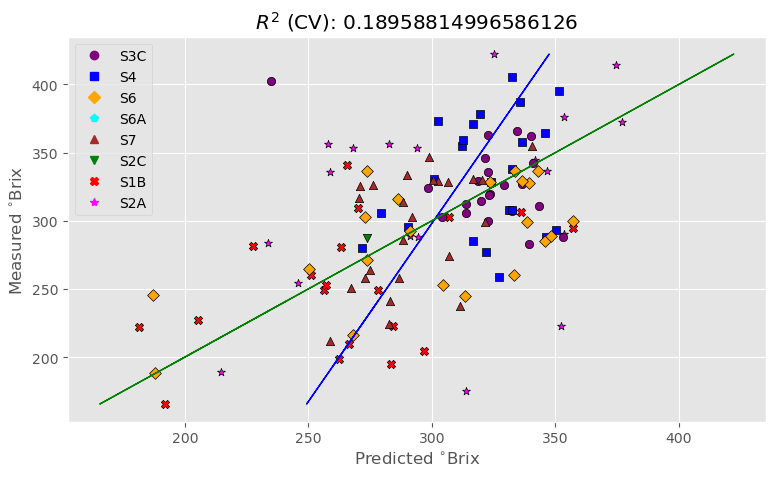

In [13]:
file_name_sla = r'E:\wenqu\2026_root\CSV\RDMC.csv'
simple_pls_cv_label_category(opt_Xc, 
                             y_RDMC,                         
                             ncomp, labels_RDMC, file_name_sla)

## SRL

In [12]:
opt_Xc, ncomp, wav, sorted_ind = optimise_pls_band_component(x_SRL, y_SRL, 20)


Optimised number of PLS components:  17
Wavelengths to be kept  48
Optimised MSEP  29.836017959303224



[ 93.27485969 134.98190842 112.60112038  84.57883055 119.00575384
 129.87034017 102.77203717 123.27974121 100.44527765 115.2847566
 140.48782835  80.20547744  91.55832066 139.32544388 135.39199764
 123.99361379 163.16348666 105.03491521 108.8065979   37.23921106
 109.8032498   77.81113029  31.48804642  60.25713589  27.53192959
  47.41956505  40.20093948  37.0493787   44.94206247  12.63193834
  53.42924542  35.98218864  37.81107967  63.18472712  50.44329642
  26.62771336  80.0018495  117.9212845  131.18729235 108.6005252
 124.1571442  162.52476759 122.39713934 103.84009487 129.81768963
 151.73878689 175.72209963 153.96144793 111.41243689 135.76023697
 128.64343581 128.47862426 141.55574788 130.92000656 126.45181263
 123.18568593 134.51615406  64.93507418  87.61888448 213.69578183
 150.42349713 104.19085051 123.83664907 124.949034   136.85581727
 136.69157171 127.93003342 160.67165919 143.52891419 122.15959037
 135.33772237 142.21912381 125.44093874 135.03178353 159.63492508
 154.8176244

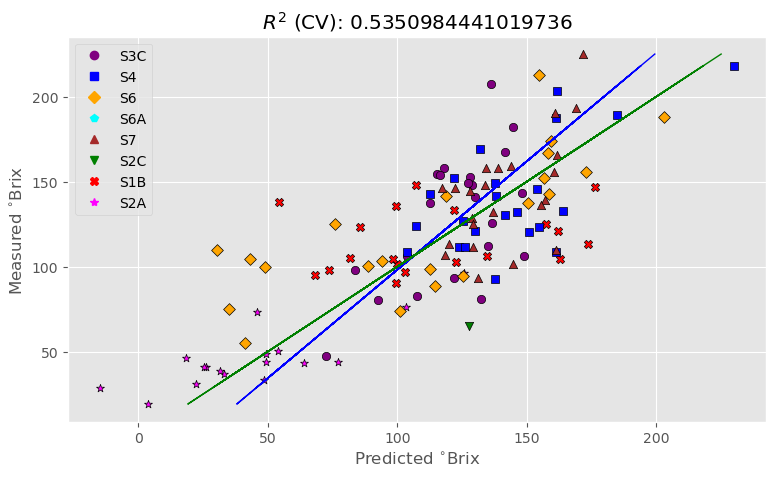

In [13]:
file_name_sla = r'E:\wenqu\2026_root\CSV\SRL.csv'
simple_pls_cv_label_category(opt_Xc, 
                             y_SRL,                         
                             ncomp, labels_SRL, file_name_sla)

In [16]:
sorted_ind

array([198, 180, 212, 206, 154,  62, 178, 144, 210, 202, 152, 174, 228,
       226, 146, 194, 227, 176, 204, 200,   5, 214, 150, 142,  16, 192,
       224, 208, 140, 172, 196,  12, 182, 160,  45, 156,  60, 170, 164,
       188,  52, 158, 162, 168, 116, 190, 222,  54,   2, 184,  48,  66,
       230, 166, 186, 235, 138, 220, 217,  58,  14, 232, 148, 246, 145,
        99,  50, 211,   6, 114,  56,   4, 128,  64,  39, 126, 238, 136,
        46,  44,  88, 236,  68, 240, 203, 234,  90, 112, 104, 110,   8,
       216, 106, 218, 175,  86, 134, 124, 141,  92,  18, 163,  22, 108,
       179, 125,  84, 153,  94, 130,  75,  96,  20,  24,  10,  76,  98,
       100,  32,  74,  95,  82,   3, 102,  34, 213,  70, 118,  80, 132,
        78,  42,  26,  72,  36,  30, 177,  40, 121,  38,   0,  28,  21,
       169, 157, 120,  79, 122, 111,  89, 143, 221,  19, 195, 205, 243,
        57,  29,  71,  51,  85, 193, 199, 159, 133, 209,  97, 189, 119,
         7, 105, 135, 225, 131, 107, 185,   9, 231, 237, 197, 12

In [19]:
optimal_pls = PLSRegression(n_components = ncomp)
optimal_pls.fit(opt_Xc, y_SRL.astype(np.float64))

coefficients = optimal_pls.coef_[:,0]
bands = b_name[sorted_ind][wav:]

print(coefficients.shape, bands.shape)

coefficients

TypeError: only integer scalar arrays can be converted to a scalar index

In [18]:
optimal_pls.intercept_


array([119.05814089])

In [ ]:
bands

## RTD
 

In [12]:
opt_Xc, ncomp, wav, sorted_ind = optimise_pls_band_component(x_RTD, y_RTD, 25)


Optimised number of PLS components:  10
Wavelengths to be kept  50
Optimised MSEP  0.07457198688682702



[0.33039349 0.22563777 0.29507393 0.3553536  0.48404248 0.42800171
 0.42387571 0.37513726 0.43113121 0.43556106 0.41063782 0.42347337
 0.57481344 0.43809908 0.55477233 0.47668339 0.45665478 0.48541428
 0.44950076 0.36486966 0.20101128 0.37047862 0.5772822  0.49985443
 0.62328058 0.48619552 0.56555812 0.47494898 0.50739388 0.59569777
 0.41900789 0.58503559 0.45925153 0.52924328 0.55442201 0.75289548
 0.34576851 0.46101218 0.52379652 0.48060924 0.46919803 0.50348402
 0.44977124 0.4946384  0.4613677  0.44742891 0.40922649 0.47954577
 0.43440055 0.48714176 0.46480777 0.48424367 0.471762   0.49218465
 0.49475088 0.51291742 0.4783252  0.47944083 0.485259   0.53611741
 0.55132529 0.5095496  0.51748231 0.57397947 0.4945258  0.49627029
 0.48028483 0.53363362 0.56839948 0.50605251 0.57881675 0.44648993
 0.54571906 0.53243626 0.52295062 0.50239188 0.54558116 0.53022109
 0.51780053 0.45601269 0.51392442 0.52839976 0.44475937 0.48361828
 0.37648533 0.45294478 0.47369487 0.49210658 0.48640777 0.4984

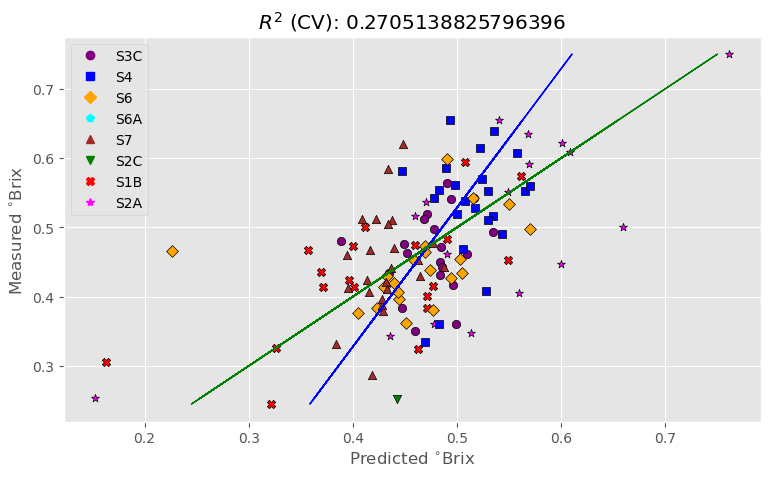

In [17]:
file_name_sla = r'E:\wenqu\2026_root\CSV\RTD.csv'
simple_pls_cv_label_category(opt_Xc, 
                             y_RTD,                         
                             ncomp, labels_RTD, file_name_sla)

In [13]:
df_svc_sla['site'][51]

'S6_Q23'

## RD

In [18]:
opt_Xc, ncomp, wav, sorted_ind = optimise_pls_band_component(x_RD, y_RD, 20)


Optimised number of PLS components:  18
Wavelengths to be kept  20
Optimised MSEP  0.026527247446852427



[0.12612787 0.11916394 0.14171784 0.13979332 0.12944273 0.14044108
 0.12346339 0.14688121 0.13793581 0.13568352 0.12828514 0.13903388
 0.12806594 0.13736459 0.14425027 0.143678   0.15427248 0.13330958
 0.1397225  0.13042663 0.13334223 0.1368215  0.13694556 0.12917988
 0.14340653 0.12029526 0.12092954 0.14170733 0.13822599 0.1400917
 0.12870486 0.15211562 0.13863889 0.14066997 0.16900815 0.13579391
 0.16278972 0.13493571 0.14509245 0.1446772  0.15811584 0.135243
 0.15234984 0.12473279 0.13534581 0.14061075 0.12568336 0.1459606
 0.13529895 0.15708234 0.16839461 0.13345113 0.15587669 0.13057638
 0.14912748 0.14108893 0.13360329 0.16488148 0.14241715 0.15654885
 0.14856468 0.13855016 0.16480496 0.16742026 0.14982903 0.14780362
 0.16084871 0.17517992 0.1584066  0.15469762 0.15777306 0.15788511
 0.14315231 0.17236078 0.15355785 0.18665153 0.15229841 0.17908868
 0.16668575 0.16330208 0.18736566 0.15025127 0.16896975 0.13612367
 0.15724423 0.16129112 0.15173772 0.14352398 0.13641566 0.15471277

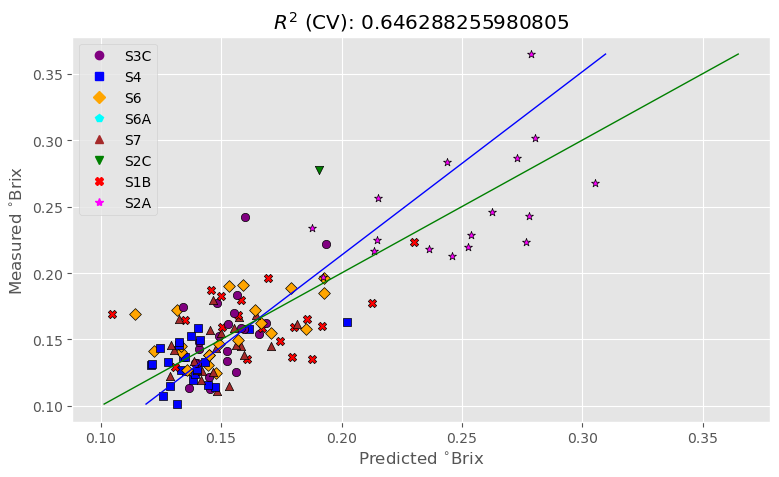

In [19]:
file_name_sla = r'E:\wenqu\2026_root\CSV\RD.csv'
simple_pls_cv_label_category(opt_Xc, 
                             y_RD,                         
                             ncomp, labels_RD, file_name_sla)

In [13]:
df_svc_d13c['site'][53]

'S6_Q27'

# SRA

In [20]:
opt_Xc, ncomp, wav, sorted_ind = optimise_pls_band_component(x_SRA, y_SRA, 25)


Optimised number of PLS components:  12
Wavelengths to be kept  41
Optimised MSEP  87.72081237422854



[618.69052831 676.50372523 778.19699691 541.39295816 471.43377886
 559.59951888 558.76248041 773.26449164 546.45761356 625.37164669
 605.98257065 470.06565803 479.76355773 637.73282581 545.91497058
 552.19059775 625.64129408 473.88806134 548.49112471 397.17942599
 635.78545269 541.32415949 229.57484406 302.23858719 253.68080196
 346.14174405 317.84797117 336.53858578 392.09635926 209.94589024
 388.58285003 270.02539548 339.22977208 423.99667583 278.61950786
 227.01611718 599.73656453 531.69545036 536.76773443 497.36425606
 543.30753632 575.17023047 575.98141271 522.4261169  555.6845321
 641.21721191 724.22223189 641.38663752 555.28692404 606.16178938
 570.79604304 602.5775575  534.87435627 597.11791715 582.69108706
 558.37039484 482.97459853 521.69823992 766.06100167 629.27850719
 515.65912449 515.74735058 532.17203883 554.78226161 540.22998462
 544.72493435 579.69683706 624.95971564 533.28685994 558.96187097
 548.35145938 584.43345974 637.86581888 593.52477848 577.06211967
 544.853199

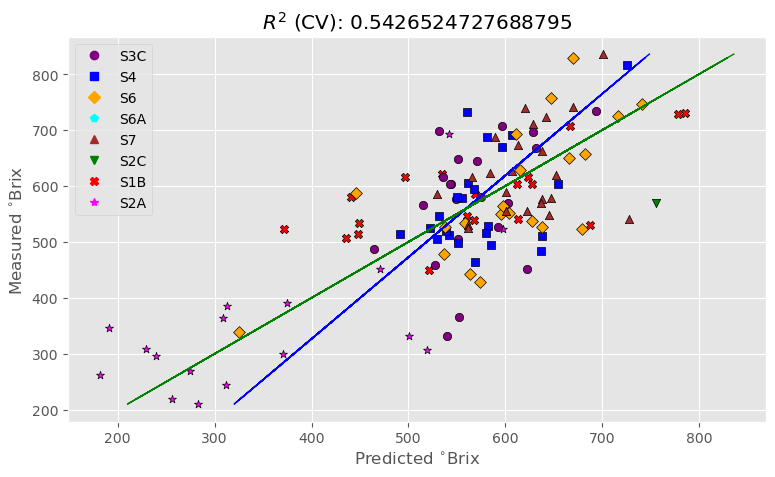

In [21]:

file_name_sla = r'E:\wenqu\2026_root\CSV\SRA.csv'
simple_pls_cv_label_category(opt_Xc, 
                             y_SRA,                         
                             ncomp, labels_SRA, file_name_sla)

In [13]:
df_svc_d15n['site'][91]

'S2A_Q17'

## RBD

In [12]:
opt_Xc, ncomp, wav, sorted_ind = optimise_pls_band_component(x_RBD, y_RBD, 20)



Optimised number of PLS components:  9
Wavelengths to be kept  41
Optimised MSEP  0.003344023374727552



[ 0.00181285  0.00176709  0.00467813  0.00047515  0.00107047  0.00062228
  0.0003634   0.00080696  0.0046309   0.00321133 -0.00078049  0.00333579
  0.0057721   0.01522658  0.00535576  0.00266616  0.00153778  0.00824799
  0.01128317  0.00223292  0.000192    0.00098919  0.00162583  0.00483923
  0.0087788   0.00854261  0.00664056  0.01552897  0.00930217  0.00922175
  0.0093211   0.00697109  0.01144258  0.00444471  0.00686062  0.01140668
  0.01334477  0.00846823  0.018868    0.00238991  0.00097907  0.01000719
  0.0073534   0.00575526  0.00393902  0.00547452  0.00406772  0.00812986
  0.00223137  0.00301058  0.00816297  0.00636591  0.00336781  0.00475506
  0.00379506  0.00590506  0.00903307  0.00707195  0.00625576  0.00471023
  0.00620243  0.00048124  0.00543594  0.00938857  0.00819727  0.00810348
  0.00814068  0.0117717   0.00961546  0.00724418  0.00630066  0.00681772
  0.00358161  0.00935579  0.00652758  0.00932544  0.00617644  0.00698896
  0.00653876  0.0108106   0.01114162  0.0091394   0

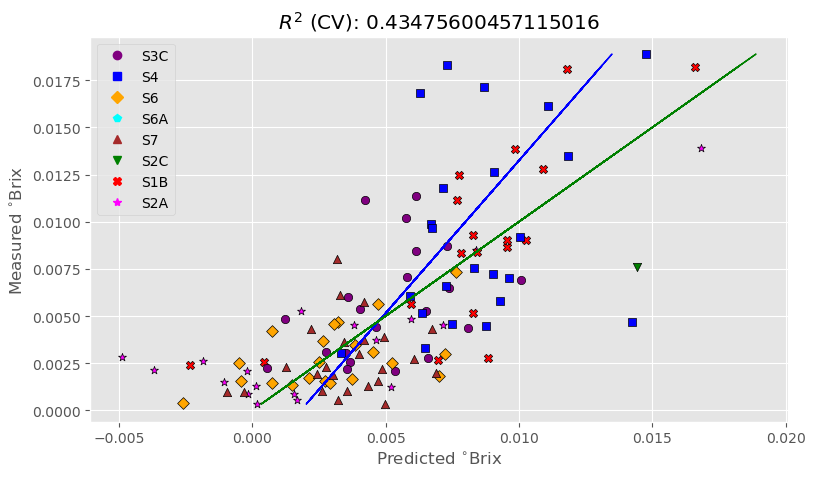

In [13]:
file_name_sla = r'E:\wenqu\2026_root\CSV\RBD.csv'
simple_pls_cv_label_category(opt_Xc, 
                             y_RBD,                         
                             ncomp, labels_RBD, file_name_sla)

In [14]:
df_svc_RBD['site'][29]

'S2A_Q17'

## RLD

In [24]:
opt_Xc, ncomp, wav, sorted_ind = optimise_pls_band_component(x_RLD, y_RLD, 20)


Optimised number of PLS components:  12
Wavelengths to be kept  50
Optimised MSEP  2.894851055736915



[-0.79620302  1.05021251  1.48927537  0.99451137  0.78780957  1.95147836
  1.80344895  1.87228384  5.78971476  1.28280957  1.45851068  1.79744134
  3.74777771  1.62943953  2.51783941  0.95287748  2.08852628  3.1878204
  3.83007395  1.79291876  1.93216299  2.94573366  3.21029025  2.98347029
  3.75630736  0.99512335  5.19624171  3.50357498  7.2473714   4.06912177
  2.6366011   2.36160828  3.31398728  5.069687    6.13718125  5.85729293
  6.40971924  3.640564    4.97965387  4.50491813  4.8462815   4.93856927
  6.34951669  4.46186684  6.51157635  5.22692239  5.21685215  5.76388271
  5.42081621  6.0659681   4.74774559  5.87813633  8.8391663   6.99497375
  5.41032711  4.16739801  4.70274232  5.69558643  6.18717732  5.91651715
  3.56793794  5.20293376  4.66306734  7.39408106  6.25123009  5.55007327
  4.53153206  6.31678224  6.470563    2.32496014  6.75373018  6.9764368
  6.00257737  7.92210256  7.79413041  4.42807464  9.57631249  6.59225819
  6.28557509  6.94619215  5.86896794  9.34425213  8.8

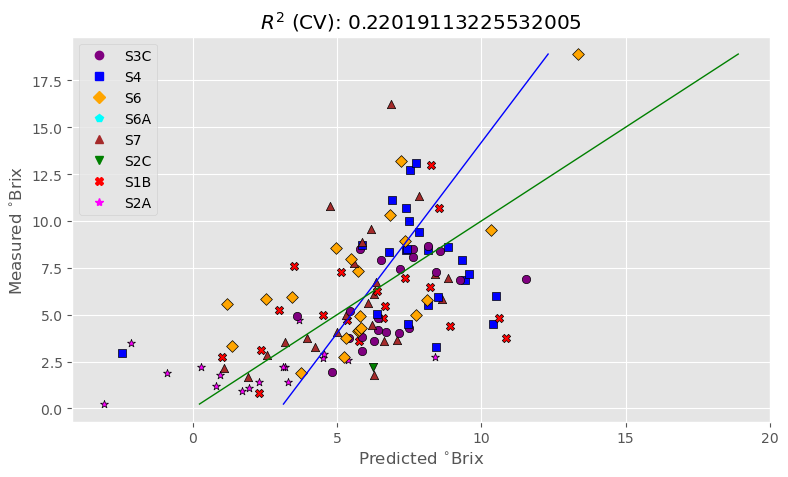

In [25]:

file_name_sla = r'E:\wenqu\2026_root\CSV\RLD.csv'
simple_pls_cv_label_category(opt_Xc, 
                             y_RLD,                         
                             ncomp, labels_RLD, file_name_sla)

## RD13C

In [26]:

opt_Xc, ncomp, wav, sorted_ind = optimise_pls_band_component(x_RD13C, y_RD13C, 25)


Optimised number of PLS components:  10
Wavelengths to be kept  64
Optimised MSEP  0.767580829376799



[-28.40687934 -28.80101424 -27.86617846 -28.80161079 -28.86774015
 -29.26045123 -27.64318727 -28.79779878 -29.02246116 -26.93600113
 -27.56050846 -29.25187417 -28.44851013 -27.10841565 -28.25549733
 -27.90968572 -27.78930387 -27.9622313  -27.88505219 -26.83609938
 -30.03172349 -26.04153462 -26.88817128 -27.18493052 -26.39266512
 -28.77690354 -28.31482115 -27.95489671 -28.46881077 -28.28816517
 -28.81574742 -27.89180783 -27.66036414 -26.34614219 -28.40344037
 -26.95208851 -27.98700576 -27.45538795 -29.5629715  -28.18059116
 -28.20722563 -26.46394223 -28.09945013 -26.23418473 -28.63409617
 -27.22599067 -28.41469722 -27.26653114 -27.48359192 -27.15922898
 -28.14706593 -27.72298057 -28.02219543 -28.63833102 -28.11691148
 -28.15080828 -27.78440052 -27.55931156 -27.96408204 -27.46937065
 -27.61049306 -28.0962318  -27.68826649 -27.63018338 -28.82161615
 -28.45913771 -27.837879   -28.37626365 -28.20975082 -28.50645057
 -28.86874238 -28.61806269 -28.11802655 -27.24191943 -28.46254643
 -28.36651

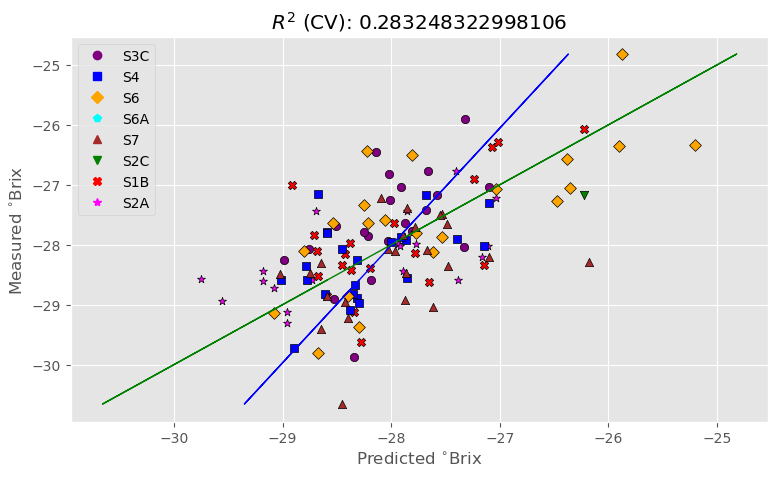

In [27]:

file_name_sla = r'E:\wenqu\2026_root\CSV\RD13C.csv'
simple_pls_cv_label_category(opt_Xc, 
                             y_RD13C,                         
                             ncomp, labels_RD13C, file_name_sla)

In [17]:
df_svc_RD13C['site'][10]

'S2A_Q15'

## RNC


Optimised number of PLS components:  9
Wavelengths to be kept  42
Optimised MSEP  1.5219975493277278

[12.89040749 12.52303832 11.21592927 12.71782116  9.30491347 13.50608129
  9.78919158  7.72057703  9.30932585  7.29673645  6.8684771   7.17593402
  9.38728185  6.50587529  8.65594434  7.4787901   8.54778977  8.46753954
  8.15944813 10.33573293  5.92240172  9.13385199  9.88607114  7.84950786
 10.45036675 10.36082645  9.52504476 11.12824523 10.34226934 13.19189847
 13.7512089  10.72149194  7.98655372 12.56192549 11.80453469 11.62975644
  7.73369052 11.18660631 13.5575363  13.60983873  8.27070197  8.38537388
 10.21762167  8.33334303  8.95088311  8.14412143  9.65896128 11.12224624
 11.84607205  9.55692613  8.82478368  9.77519132 11.27793534  9.67804836
  9.09932037  9.97722682 10.1811178  10.31593128  9.28101164 10.30939428
  9.37371468 10.30363598  9.56287478  9.82254491 10.65373841  9.37982147
 12.71801173 11.60562594 11.10760153  9.73970401  9.98199493 10.44941162
 11.12388043  9.83090

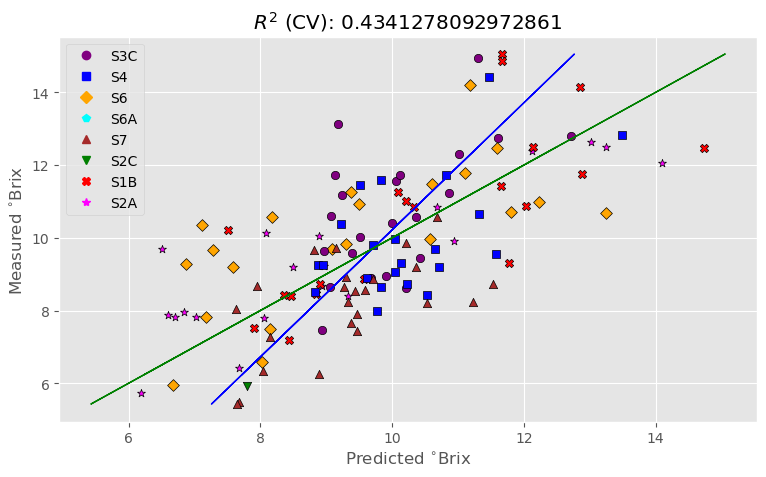

In [28]:
opt_Xc, ncomp, wav, sorted_ind = optimise_pls_band_component(x_RNC, y_RNC, 20)
file_name_sla = r'E:\wenqu\2026_root\CSV\RNC.csv'
simple_pls_cv_label_category(opt_Xc, 
                             y_RNC,                         
                             ncomp, labels_RNC, file_name_sla)

## RD15N


Optimised number of PLS components:  18
Wavelengths to be kept  28
Optimised MSEP  1.1249752543889617

[ 1.90884994  0.45240327  0.92346647  0.84053313  1.4665859   1.67422134
 -0.47214341 -1.50756893 -0.84556108 -1.37067174 -0.69389511 -1.97966457
  0.90601432 -3.84036088  0.37282973 -3.58917324 -0.87536606 -0.75327648
 -2.51989718 -0.03337769  1.75614907 -3.67973069  2.06874295  3.21147177
  3.02705817  2.54727852  0.05668737  1.49988744  1.25969723 -0.1734118
  0.2679943   2.55432295  1.77926765  2.44900486  2.48846032  3.89955542
  1.67370049 -1.63811313  0.2780776   1.179527   -0.66083311  2.07583436
  0.21561111  0.15943275  2.42161505  1.50334127 -0.03704216 -1.12439541
  1.55647576 -0.26916754  0.73701695  0.07865092 -0.15541238  0.40958957
 -1.10016979 -0.16517563  0.08257776 -0.04673132  0.28594643  0.77584208
 -0.34913462  0.47410434  0.04392022 -0.04682216  0.6025665  -1.12556621
  0.42487654  0.83494339 -0.4491829   0.36286228 -0.70060589 -1.04069466
 -1.78339806 -1.08681

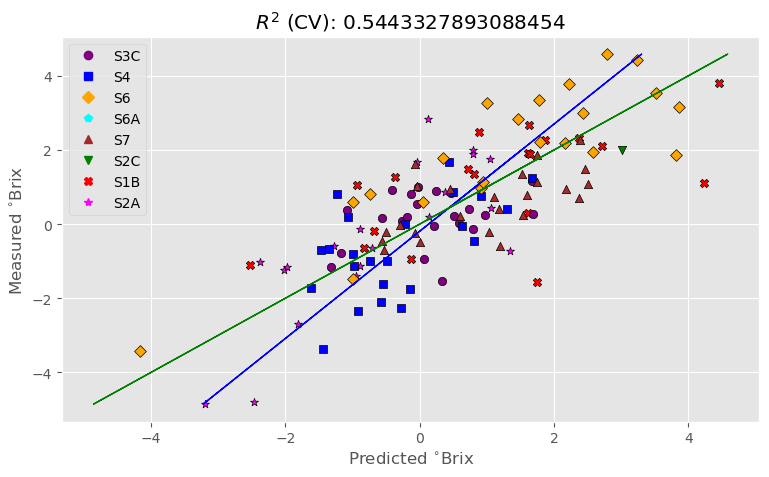

In [29]:
opt_Xc, ncomp, wav, sorted_ind = optimise_pls_band_component(x_RD15N, y_RD15N, 20)
file_name_sla = r'E:\wenqu\2026_root\CSV\RD15N.csv'
simple_pls_cv_label_category(opt_Xc, 
                             y_RD15N,                         
                             ncomp, labels_RD15N, file_name_sla)

## RCN


Optimised number of PLS components:  6
Wavelengths to be kept  23
Optimised MSEP  8.317190272158347

[32.63285894 32.69646306 47.69429662 37.64159371 47.94911793 33.49472835
 53.13744784 55.37206573 53.58406727 68.92120534 66.58834246 63.11906715
 54.18097342 84.14823764 52.34883467 64.08184835 57.31170085 60.78690899
 66.36759906 61.70027083 70.38819521 49.28546635 52.36464381 59.23932633
 48.00372688 41.49429423 47.12290003 35.36479122 41.10806046 36.9589464
 35.70783754 43.69987618 47.67350164 31.07723874 42.42304923 45.91075712
 61.88060539 40.99946486 37.77065387 37.89269466 57.87097582 49.79794012
 50.40420334 52.75582103 63.12938872 50.29498117 46.23336359 43.43414905
 41.06732845 46.21374613 44.3963339  46.70417393 41.12965414 50.3711066
 46.82806178 42.34701338 44.29208286 42.25418991 47.91337819 44.60941106
 47.6149533  47.65628023 48.42979646 44.81865579 41.90278472 47.30587095
 32.39709392 36.61943496 37.73972419 46.61654239 48.73742637 45.36312452
 42.70768978 48.89031826

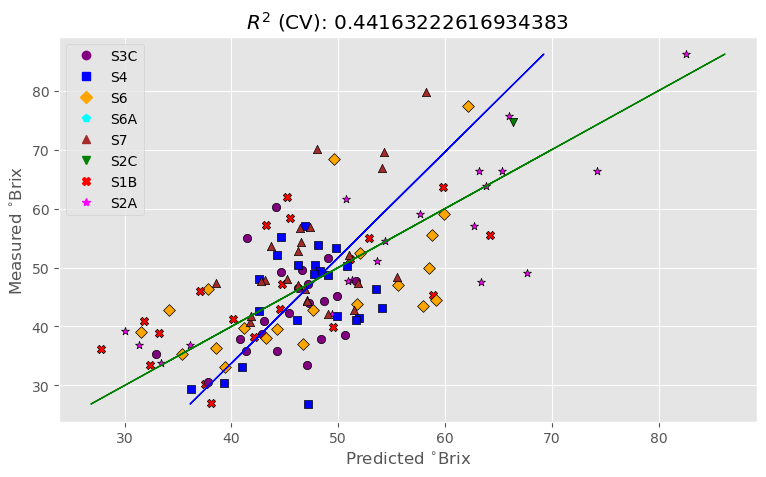

In [30]:
opt_Xc, ncomp, wav, sorted_ind = optimise_pls_band_component(x_RCN, y_RCN, 20)
file_name_sla = r'E:\wenqu\2026_root\CSV\RCN.csv'
simple_pls_cv_label_category(opt_Xc, 
                             y_RCN,                         
                             ncomp, labels_RCN, file_name_sla)

## RCC


Optimised number of PLS components:  5
Wavelengths to be kept  24
Optimised MSEP  24.667010149370434

[439.7647513  461.91763927 461.87882944 476.53580318 446.43090492
 476.02077404 490.4282329  510.43347609 466.3321944  513.03683071
 514.18818119 479.34356863 503.72510476 504.37256576 463.88170147
 510.6918425  481.84705835 485.29493762 524.32408508 510.98837311
 435.03589045 479.23599311 450.77683172 437.89668885 475.91968188
 446.44796326 470.75934235 419.7056781  419.16963416 435.38153782
 438.92083859 440.1405881  429.42985262 447.90246358 447.83751461
 474.18187871 462.55124049 488.58965422 500.22919927 505.01151167
 470.0364371  468.89627961 474.54434098 474.05863615 466.4522461
 441.94818842 412.20557944 438.01665616 470.57926222 440.80180614
 450.66719358 445.32891273 449.10436506 458.91645923 446.8688958
 470.47968147 461.84053576 446.78982974 443.30543427 462.67299214
 448.01312655 439.240634   462.58733943 467.15292678 451.78922614
 453.9344545  440.26797092 455.71646884 4

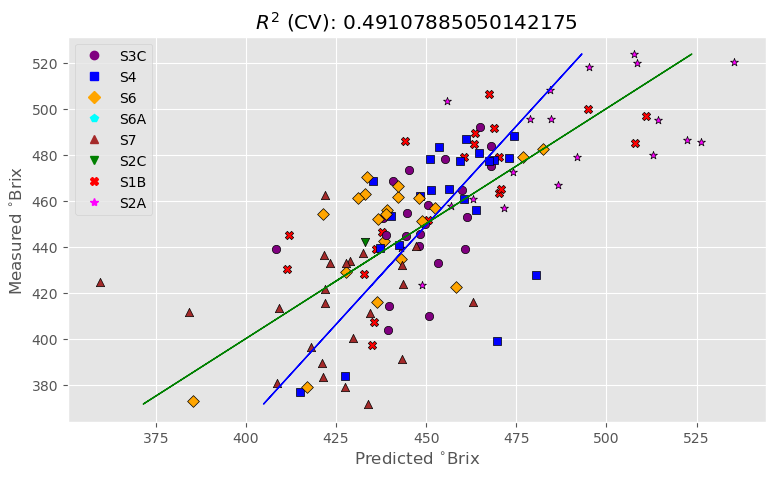

In [12]:
opt_Xc, ncomp, wav, sorted_ind = optimise_pls_band_component(x_RCC, y_RCC, 20)
file_name_sla = r'E:\wenqu\2026_root\CSV\RCC.csv'
simple_pls_cv_label_category(opt_Xc, 
                             y_RCC,                         
                             ncomp, labels_RCC, file_name_sla)

In [13]:
df_svc_ldmc['site'][96]

'S2A_Q28'

In [3]:
import pandas as pd

df1 = pd.read_csv(r"E:\wenqu\2026_root\soil core trait_full_edited.csv")
df2 = pd.read_csv(r"D:\wenqu\2024_data\Fw_2024_aboveground\2022_2024_spectral.csv")

# inner join (only matching rows)
df_joined = pd.merge(df1, df2, on="site", how="inner")

df_joined.to_csv(r"E:\wenqu\2026_root\root_trait.csv", index=False)


In [30]:
import pandas as pd
import numpy as np

# ===== 1. file paths =====
input_csv = r"D:\wenqu\2024_data\SVC\update3_vascular\spectral_trait_mean.csv"
# output_csv_all = r"D:\wenqu\2024_data\SVC\update3_vascular\PC_with_zscores.csv"
output_csv_clean = r"D:\wenqu\2024_data\SVC\update3_vascular\PN_without_zscores.csv"

# ===== 2. column name =====
col = "CWM_log10_LNC"   # <-- change this to your column name

# ===== 3. read csv =====
df = pd.read_csv(input_csv)

# make sure column is numeric
df[col] = pd.to_numeric(df[col], errors="coerce")

# ===== 4. compute z-score =====
mean = df[col].mean()
std = df[col].std()

df["z_score"] = (df[col] - mean) / std

# ===== 5. flag outliers (|z| > 3) =====
df["outlier"] = df["z_score"].abs() > 3

# ===== 6. remove outliers (optional) =====
df_clean = df[df["outlier"] == False]

# ===== 7. save results =====
# df.to_csv(output_csv_all, index=False)
df_clean.to_csv(output_csv_clean, index=False)

print("Done!")
print("Total rows:", len(df))
print("Outliers removed:", df["outlier"].sum())


Done!
Total rows: 138
Outliers removed: 1
